This notebook creates training and test datasets from the complete logitudinal dataset created from the previous notebook. 

In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
run_date_str = '20231010'
s3_output = f's3://toast-datascience-sandbox/PradeepA/pre90_pd_model/{run_date_str}' # output directory

df = pd.read_parquet(f's3://toast-datascience-sandbox/PradeepA/pre90_pd_model/{run_date_str}/processed_train.parquet') # read 'processed_train.parquet' generated from the previous notebook

In [3]:
df.head()

,rid,dt,totalRevenue,totalCreditCardRevenue,tx_hours,noprocessing,label_90,state,first_order_date,parent_market_segment,...,days_no_gpv_28d,days_no_gpv_28d_28ddiff,tx_hours_mean_14d,tx_hours_median_14d,tx_hours_median_28d,tx_hours_median_28d_28ddiff,has_oo_mod,has_gc_mod,noprocessing_last_90d,flag_ge50_3d_over_7d
365,9,2018-01-01,882.49,643.54,9.0,0.0,0.0,MA,2013-07-02,SMB,...,0.0,0.0,9.000000,9.0,9.0,0.0,0,0,0.0,0
366,9,2018-01-02,1041.34,733.12,10.0,0.0,0.0,MA,2013-07-02,SMB,...,0.0,0.0,9.500000,9.5,9.5,0.0,0,0,0.0,0
367,9,2018-01-03,1104.81,815.09,10.0,0.0,0.0,MA,2013-07-02,SMB,...,0.0,0.0,9.666667,10.0,10.0,0.0,0,0,0.0,1
368,9,2018-01-04,0.00,0.00,0.0,0.0,0.0,MA,2013-07-02,SMB,...,1.0,0.0,7.250000,9.5,9.5,0.0,0,0,0.0,1
369,9,2018-01-05,631.44,409.91,9.0,0.0,0.0,MA,2013-07-02,SMB,...,1.0,0.0,7.600000,9.0,9.0,0.0,0,0,0.0,1


In [4]:
# To make training samples similar to the accounts we're going to predict on,
# only keep samples where the restaurants have been on platform for 90 days and don't have 30-day no processing in the past 30 days
df['days_delta_first_obs'] = (
    df['dt'] - df.groupby('rid')['dt'].transform('min')
).dt.days
# df = df.loc[(df['days_delta_first_obs'] >= 30) & (df['days_delta_first_obs'] <= 89) & \
#             (df['noprocessing'] == 0)]

df = df.loc[(df['days_delta_first_obs'] <= 90) & (df['noprocessing'] == 0)]

In [5]:
# df = df[df['days_with_toast']<=90]

In [6]:
horizon = 90  # prediction horizon
# variables to keep
keep_vars = ['rid', 'dt', 'label_90', 'flag_ge50_3d_over_7d',
             'state', 'parent_market_segment', 'restaurant_type', 'account_restaurant_category', 'days_delta_first_obs',
             
       'first_loan_date', 'days_with_toast', 'months_with_toast',
        'first_loan_date_90d', 
             
       'has_oo_mod', 'has_gc_mod',
             'noprocessing_last_90d', 
             
       'gpv_mean_90d', 'gpv_mean_28d', 'gpv_median_28d',
        'gpv_cv_90d', 
          'log_gpv_std_90d',
             'gpv_median_28d_mean_90d_diff', 'gpv_median_28d_median_84d_diff',
        'gpv_median_28d_28ddiff', 'gpv_median_28d_84ddiff', 
            
             'gpv_per_hour_median_28d', 'gpv_per_hour_median_28d_28ddiff', 'days_no_gpv_90d',
             
        'days_no_gpv_28d', 'days_no_gpv_28d_28ddiff',
             
       'tx_hours_mean_14d', 'tx_hours_median_14d', 'tx_hours_median_28d', 'tx_hours_median_28d_28ddiff',
       ]

In [7]:
from toast_cap.utilities.pd_functions import train_test_split_by_time, non_overlapping_xs

## sample every 14 days
sample_stride = 14
num_test_days = 150  # the last 120 days in the dataset will be used as the test dataset 

# reduce the dataset
df_subset = df.loc[(df['dt'] >= pd.to_datetime('2018-07-01')), keep_vars].copy()

In [8]:
# remove covid data
excl_covid_start = pd.to_datetime('2020-03-10') - pd.to_timedelta(horizon, unit = 'd')
excl_covid_end = pd.to_datetime('2020-12-31')
df_subset = df_subset.loc[(~df_subset['dt'].between(excl_covid_start, excl_covid_end))]

# create train test split and take cross-sectional samples every 14 days
df_train, df_test = train_test_split_by_time(df=df_subset, horizon=horizon, test_buffer_days=num_test_days)
df_train_xs = non_overlapping_xs(df_train, horizon=sample_stride)
df_test_xs = non_overlapping_xs(df_test, horizon=sample_stride)

print(f"training sample date range: {df_train_xs['dt'].min().strftime('%Y-%m-%d')}, {df_train_xs['dt'].max().strftime('%Y-%m-%d')}")
print(f"test sample date range: {df_test_xs['dt'].min().strftime('%Y-%m-%d')}, {df_test_xs['dt'].max().strftime('%Y-%m-%d')}")

df_train_xs.to_parquet(os.path.join(s3_output, 'train_xs.parquet'))
df_test_xs.to_parquet(os.path.join(s3_output, 'test_xs.parquet'))

training sample date range: 2018-07-15, 2022-11-13
test sample date range: 2023-02-21, 2023-07-11


In [9]:
df_train_xs['days_delta_first_obs'].value_counts()

40    6323
54    6266
33    6250
47    6190
68    6177
      ... 
56     920
35     871
49     849
63     833
77     818
Name: days_delta_first_obs, Length: 62, dtype: int64

<Axes: >

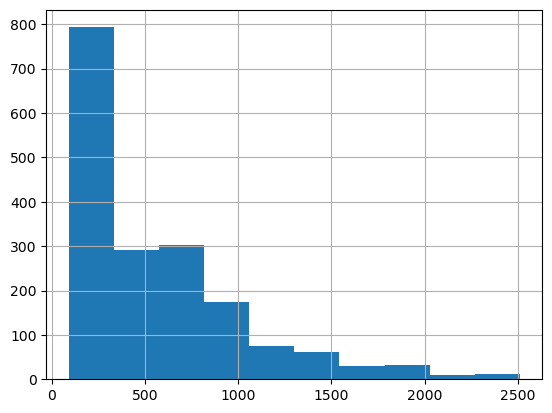

In [10]:
df_train_xs[df_train_xs['days_with_toast']>90]['days_with_toast'].hist()

<Axes: >

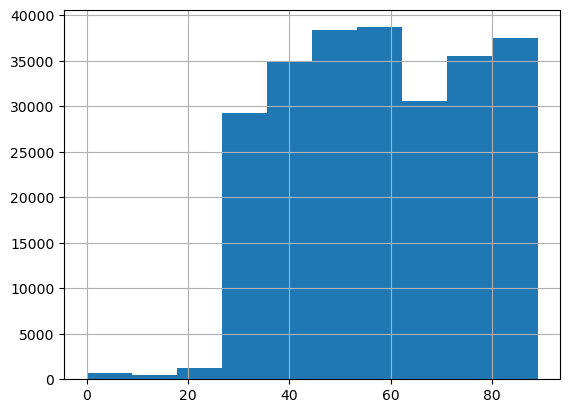

In [11]:
df_train_xs[df_train_xs['days_with_toast']<90]['days_with_toast'].hist()

<Axes: >

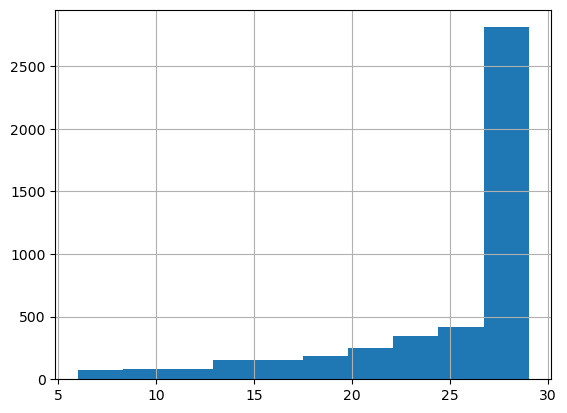

In [12]:
df_train_xs[(df_train_xs['days_with_toast']>5) & (df_train_xs['days_with_toast']<30)]['days_with_toast'].hist()

In [13]:
df_train_xs.size

8605060

In [14]:
df_train_xs['days_delta_first_obs'].value_counts(ascending=False)

40    6323
54    6266
33    6250
47    6190
68    6177
      ... 
56     920
35     871
49     849
63     833
77     818
Name: days_delta_first_obs, Length: 62, dtype: int64

<Axes: >

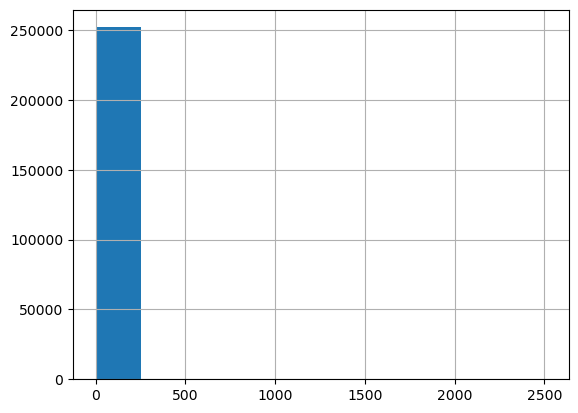

In [15]:
df_train_xs['days_with_toast'].hist()

<Axes: >

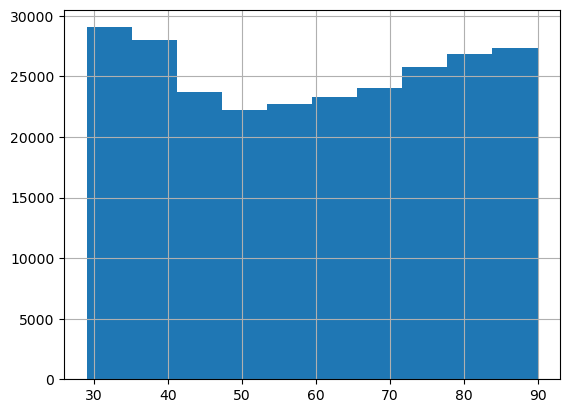

In [16]:
df_train_xs[df_train_xs['days_delta_first_obs']<=90]['days_delta_first_obs'].hist()

In [17]:
df_train_xs['flag_ge50_3d_over_7d'].value_counts()

1    237298
0     15792
Name: flag_ge50_3d_over_7d, dtype: int64

In [19]:
df_train_xs['flag_ge50_3d_over_7d'].shape

(253090,)